In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from scipy import stats

In [2]:
OUTPUT_DIR = r"C:\Courses\Innopolis\2026\ВЭД\Данные2"

In [3]:
df_po = pd.read_csv(f"{OUTPUT_DIR}\\fact_purchase_orders_clean.csv")

In [4]:
df_po.columns

Index(['po_id', 'order_date', 'supplier_id', 'product_id', 'transport_mode_id',
       'origin_port_id', 'destination_port_id', 'quantity', 'unit_price_usd',
       'total_value_usd', 'currency_code', 'fx_rate_to_usd',
       'total_value_local', 'freight_cost_usd', 'insurance_cost_usd',
       'customs_duty_usd', 'incoterm', 'payment_method',
       'expected_delivery_days', 'actual_delivery_days',
       'port_congestion_at_order', 'shock_index_at_order',
       'supplier_reliability', 'final_state', 'is_fraud', 'fraud_type'],
      dtype='object')

In [5]:
id_cols = ["po_id"]
cat_cols = ["product_id", "transport_mode_id", "origin_port_id", "destination_port_id", "incoterm", "payment_method"]
num_cols = [
    "quantity", 
    "unit_price_usd", 
    "freight_cost_usd", 
    "insurance_cost_usd",
    "customs_duty_usd", 
    "expected_delivery_days", 
    "actual_delivery_days", 
    "port_congestion_at_order", 
    "shock_index_at_order",
    "supplier_reliability",
]

In [6]:
data = df_po.copy()
data[cat_cols] = data[cat_cols].astype("category")
data = data.sort_values(by = "po_id")
data = data.set_index("po_id")
data = data[num_cols + cat_cols]
#data = pd.get_dummies(data[num_cols + cat_cols], drop_first = True, dtype = int)
data = data.dropna()

cols = data.columns

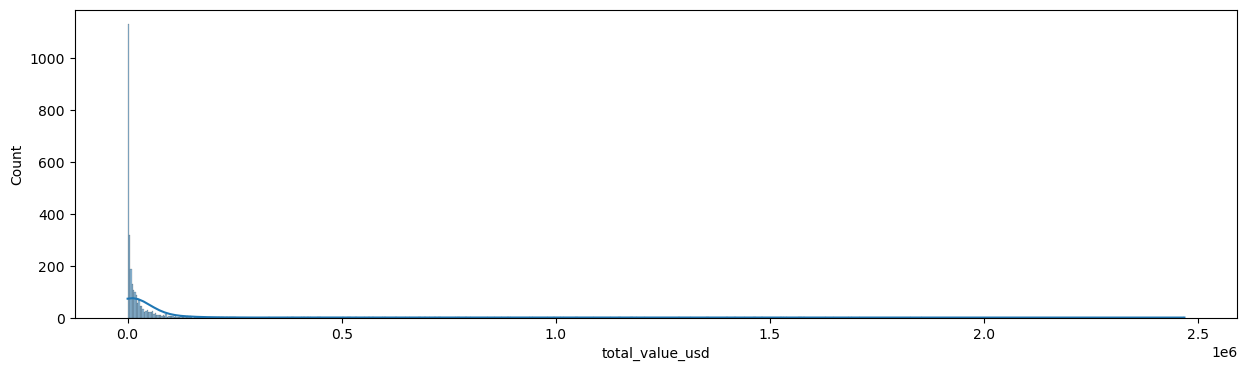

In [9]:
fig, ax = plt.subplots(1,1,figsize = (15,4))
sns.histplot(x = 'total_value_usd', data = df_po, kde = True, ax = ax)
plt.show()

In [32]:
def visualise_anomalies(flag_col):
    fig, ax = plt.subplots(2,2,figsize = (12,10))
    sns.scatterplot(x = "freight_cost_usd", y = "insurance_cost_usd", data = data, hue = flag_col, ax = ax[0,0])
    sns.scatterplot(x = "unit_price_usd", y = "port_congestion_at_order", data = data, hue = flag_col, ax = ax[0,1])
    sns.scatterplot(x = "freight_cost_usd", y = "customs_duty_usd", data = data, hue = flag_col, ax = ax[1,0])
    sns.scatterplot(x = "actual_delivery_days", y = "customs_duty_usd", data = data, hue = flag_col, ax = ax[1,1])
    plt.tight_layout()
    plt.show()

# Z-score

In [10]:
anomaly_vars = ["freight_cost_usd", "quantity",  "unit_price_usd", "insurance_cost_usd", "customs_duty_usd"]

def get_z_anomaly(df, anomaly_var):
    df[f"z_{anomaly_var}"] = np.abs(stats.zscore(df[anomaly_var].dropna()))
    df[f"flag_z_{anomaly_var}"] = np.where(df[f"z_{anomaly_var}"]>3, 1, 0)
    print(f"Аномалий {anomaly_var} по Z-score (|z| > 3): {df[df[f"flag_z_{anomaly_var}"] == 1].shape[0]}")
    return df.drop(f"z_{anomaly_var}", axis = 1)

for anomaly_var in anomaly_vars:
    data = get_z_anomaly(data, anomaly_var)

Аномалий freight_cost_usd по Z-score (|z| > 3): 40
Аномалий quantity по Z-score (|z| > 3): 0
Аномалий unit_price_usd по Z-score (|z| > 3): 81
Аномалий insurance_cost_usd по Z-score (|z| > 3): 52
Аномалий customs_duty_usd по Z-score (|z| > 3): 51


In [11]:
z_anomalies = ["flag_z_freight_cost_usd", "flag_z_quantity", "flag_z_unit_price_usd", "flag_z_insurance_cost_usd", "flag_z_customs_duty_usd"]
data[z_anomalies].sum()

flag_z_freight_cost_usd      40
flag_z_quantity               0
flag_z_unit_price_usd        81
flag_z_insurance_cost_usd    52
flag_z_customs_duty_usd      51
dtype: int64

IndexError: list index out of range

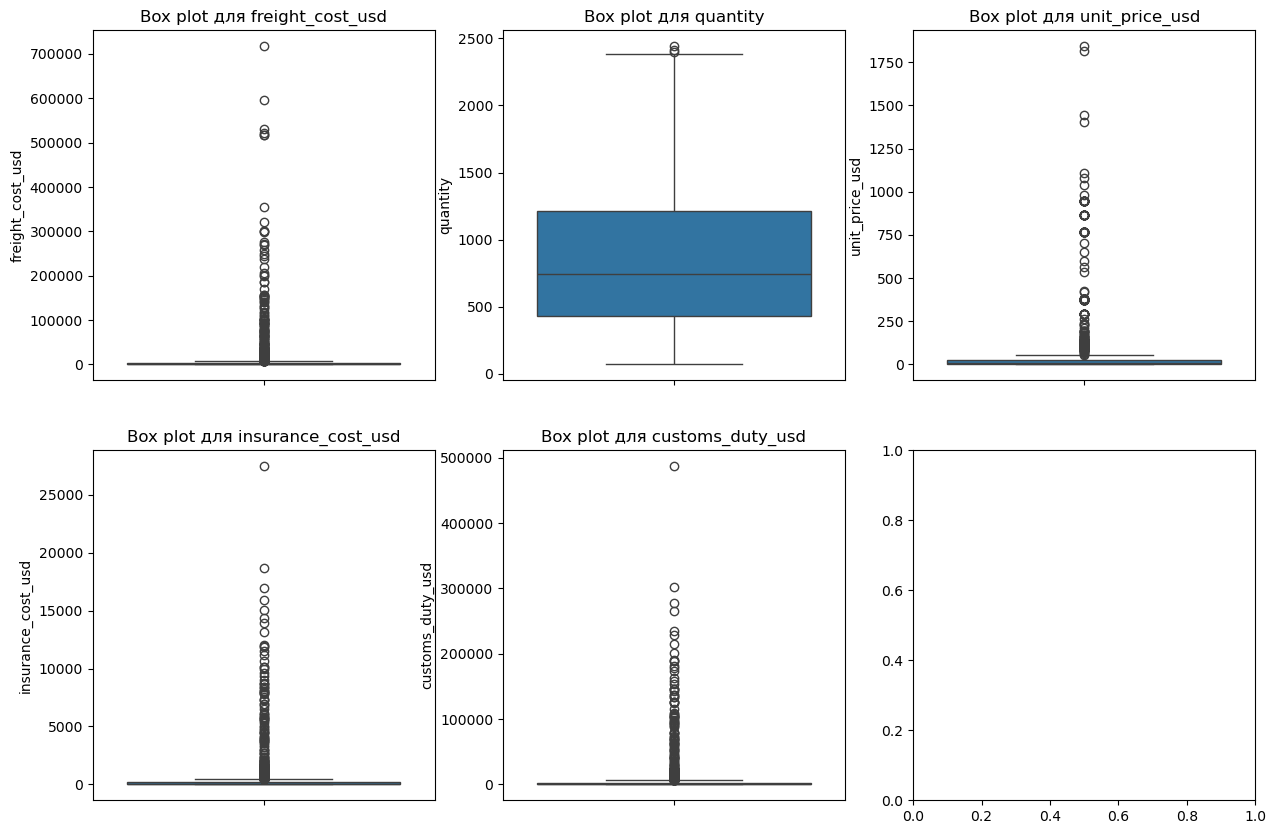

In [12]:
fig, axes = plt.subplots(2, 3, figsize = (15, 10))
for i, ax in enumerate(axes.flatten()):
    sns.boxplot(data[anomaly_vars[i]], ax = ax)
    ax.set_title(f"Box plot для {anomaly_vars[i]}")


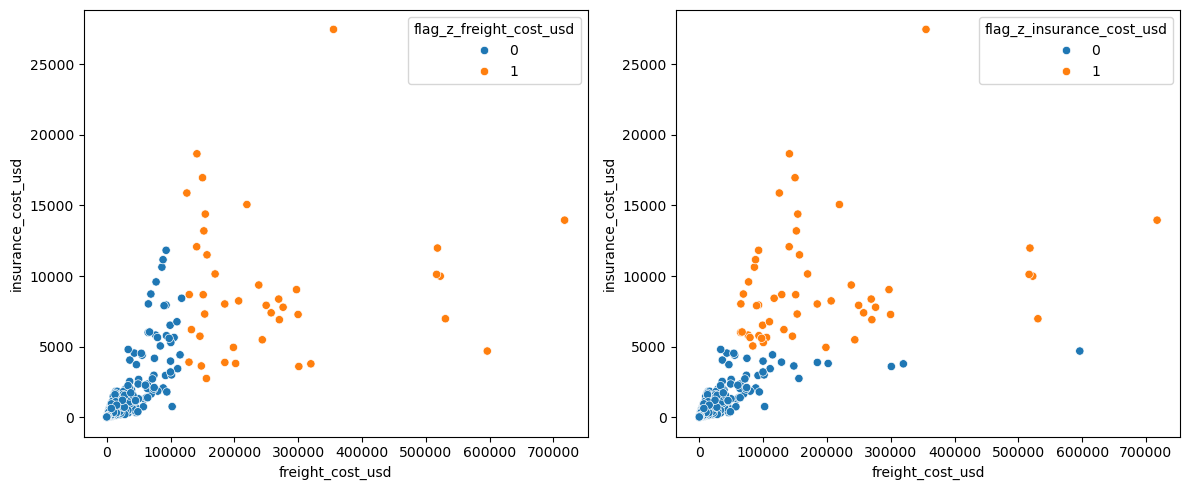

In [13]:
fig, ax = plt.subplots(1,2,figsize = (12,5))
sns.scatterplot(x = "freight_cost_usd", y = "insurance_cost_usd", data = data, hue = "flag_z_freight_cost_usd", ax = ax[0])
sns.scatterplot(x = "freight_cost_usd", y = "insurance_cost_usd", data = data, hue = "flag_z_insurance_cost_usd", ax = ax[1])
plt.tight_layout()
plt.show()

# IQR

In [14]:
def get_iqr_anomaly(df, anomaly_var, factor = 1.5):
    Q1 = df[anomaly_var].quantile(0.25)
    Q3 = df[anomaly_var].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    df[f"flag_iqr_{anomaly_var}"] = np.where((df[anomaly_var] < lower) | (df[anomaly_var] > upper), 1, 0)
    print(f"Аномалий {anomaly_var} по IQR: {df[df[f"flag_iqr_{anomaly_var}"] == 1].shape[0]}")
    return data

for anomaly_var in anomaly_vars:
    data = get_iqr_anomaly(data, anomaly_var)

Аномалий freight_cost_usd по IQR: 328
Аномалий quantity по IQR: 3
Аномалий unit_price_usd по IQR: 335
Аномалий insurance_cost_usd по IQR: 299
Аномалий customs_duty_usd по IQR: 308


In [15]:
iqr_anomalies = ["flag_iqr_freight_cost_usd", "flag_iqr_quantity", "flag_iqr_unit_price_usd", "flag_iqr_insurance_cost_usd", "flag_iqr_customs_duty_usd"]
data[iqr_anomalies].sum()

flag_iqr_freight_cost_usd      328
flag_iqr_quantity                3
flag_iqr_unit_price_usd        335
flag_iqr_insurance_cost_usd    299
flag_iqr_customs_duty_usd      308
dtype: int64

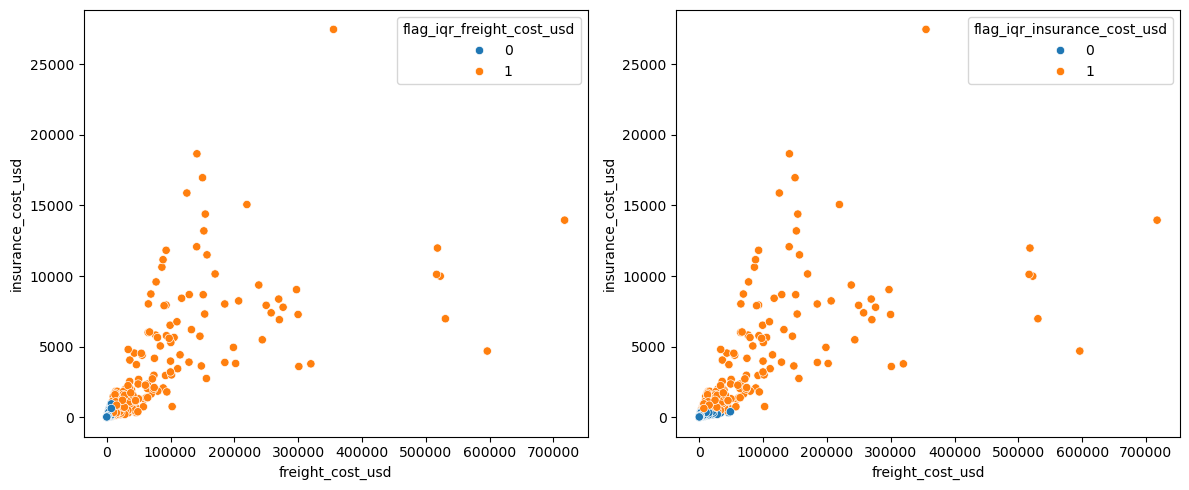

In [16]:
fig, ax = plt.subplots(1,2,figsize = (12,5))
sns.scatterplot(x = "freight_cost_usd", y = "insurance_cost_usd", data = data, hue = "flag_iqr_freight_cost_usd", ax = ax[0])
sns.scatterplot(x = "freight_cost_usd", y = "insurance_cost_usd", data = data, hue = "flag_iqr_insurance_cost_usd", ax = ax[1])
plt.tight_layout()
plt.show()

# Local Outlier Factor

In [17]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

In [18]:
lof = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LocalOutlierFactor(n_neighbors=20, contamination=0.05))
])
lof_labels = lof.fit_predict(data[num_cols + cat_cols])

data["flag_lof_anomaly"] = (lof_labels == -1)*1
print("LOF anomalies:", data["flag_lof_anomaly"].sum())

LOF anomalies: 124


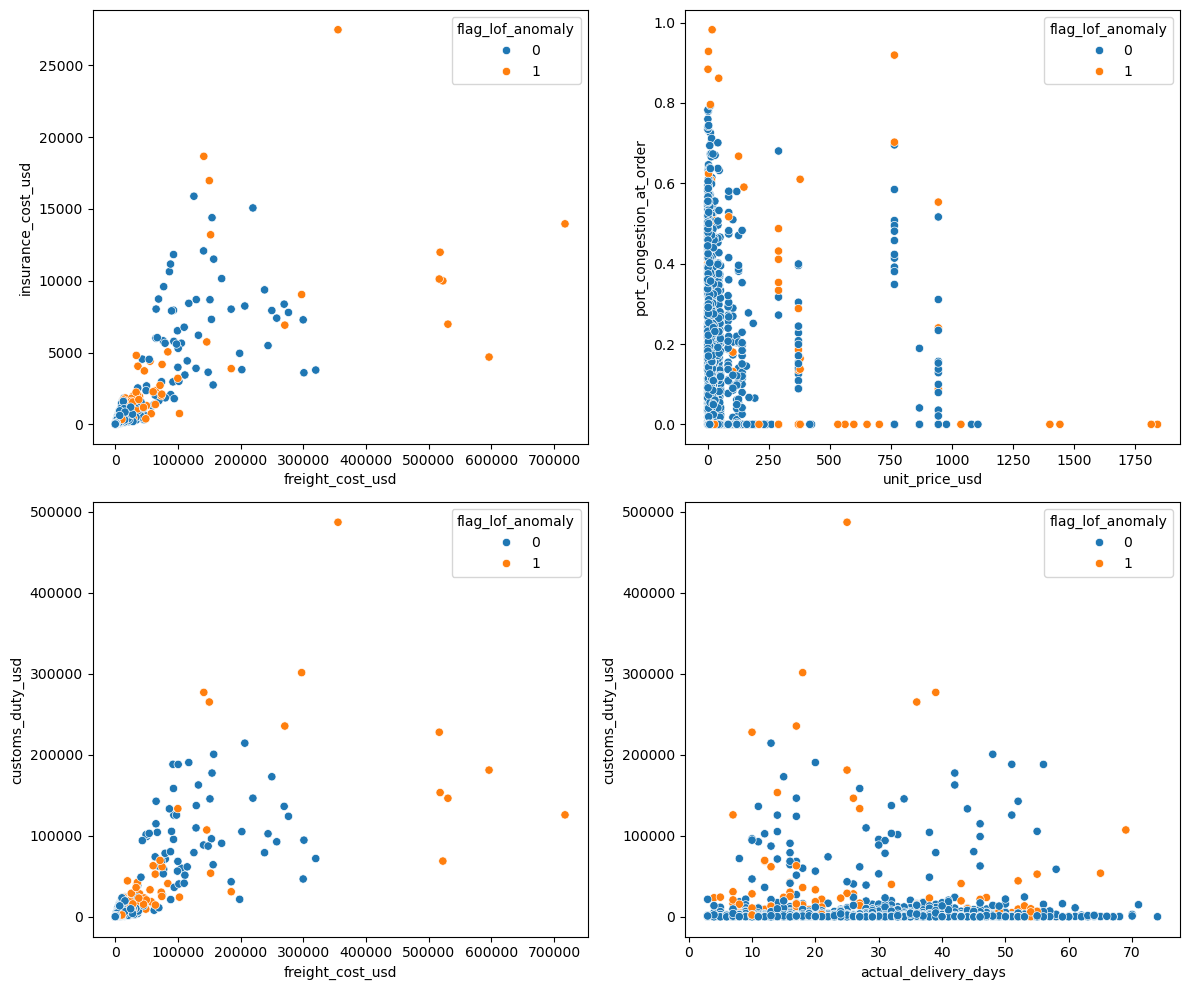

In [33]:
visualise_anomalies("flag_lof_anomaly")

# Isolation Forest

In [22]:
iso = Pipeline([
    ("preprocessor", preprocessor),
    ("model", IsolationForest(contamination=0.05, random_state=42))
])

iso.fit(data[num_cols + cat_cols])

iso_labels = iso.predict(data[num_cols + cat_cols])

data["flag_if_anomaly"] = (iso_labels == -1)*1

print("Isolation Forest anomalies:", data["flag_if_anomaly"].sum())

Isolation Forest anomalies: 124


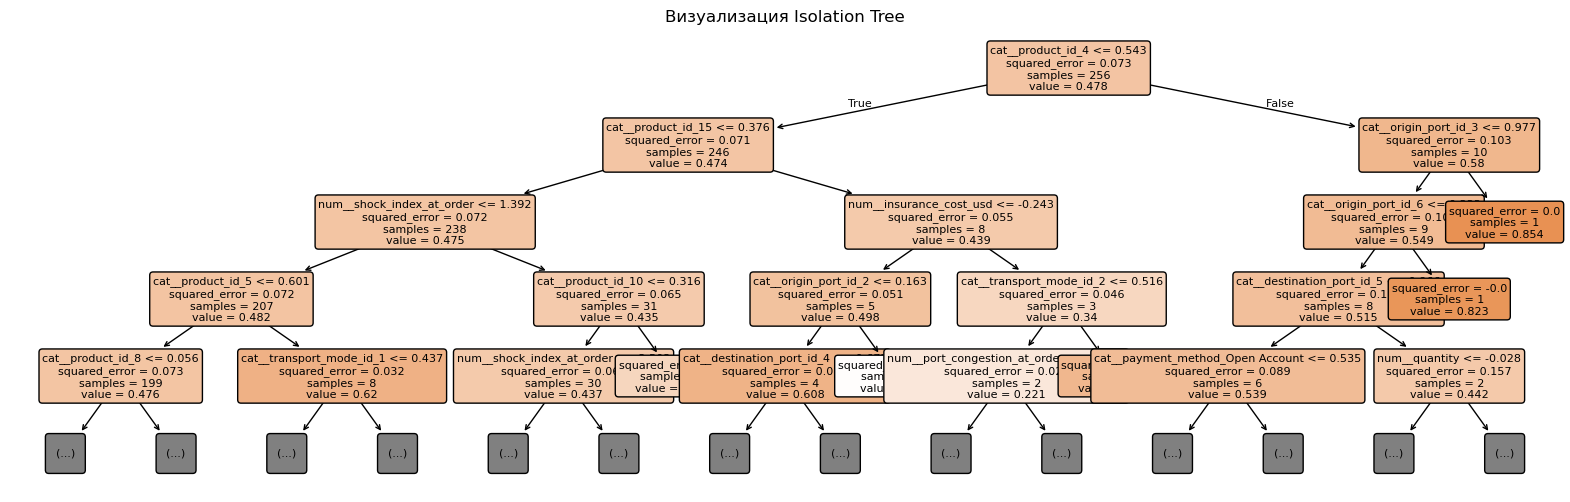

In [28]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 6))
plot_tree(iso.named_steps["model"].estimators_[1], 
          feature_names=iso.named_steps["preprocessor"].get_feature_names_out(), 
          filled=True, 
          rounded=True,
          max_depth=4,
          fontsize = 8)
plt.title("Визуализация Isolation Tree")
plt.show()

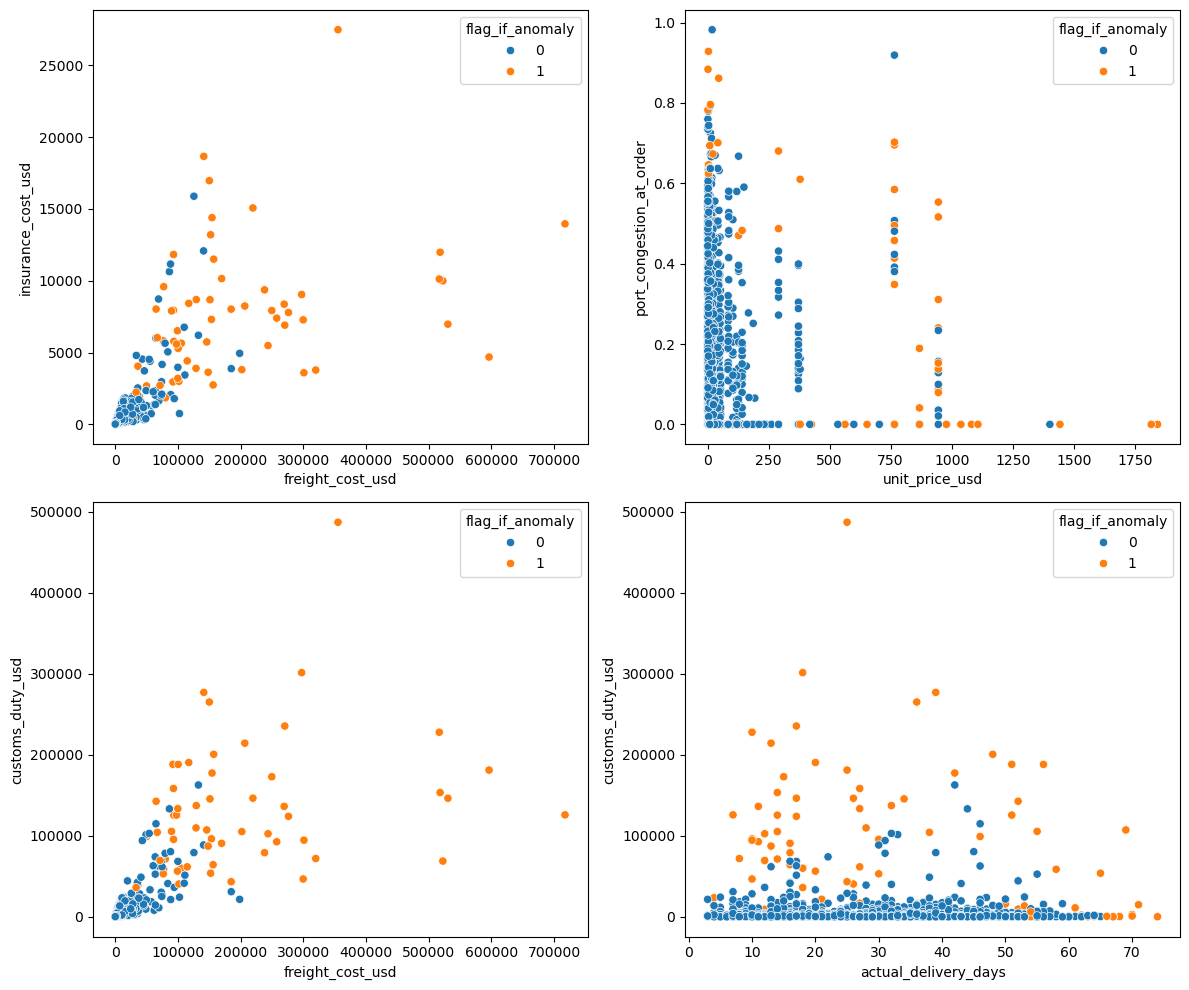

In [25]:
fig, ax = plt.subplots(2,2,figsize = (12,10))
sns.scatterplot(x = "freight_cost_usd", y = "insurance_cost_usd", data = data, hue = "flag_if_anomaly", ax = ax[0,0])
sns.scatterplot(x = "unit_price_usd", y = "port_congestion_at_order", data = data, hue = "flag_if_anomaly", ax = ax[0,1])
sns.scatterplot(x = "freight_cost_usd", y = "customs_duty_usd", data = data, hue = "flag_if_anomaly", ax = ax[1,0])
sns.scatterplot(x = "actual_delivery_days", y = "customs_duty_usd", data = data, hue = "flag_if_anomaly", ax = ax[1,1])
plt.tight_layout()
plt.show()

# One Class SVM

In [29]:
svm = Pipeline([
    ("preprocessor", preprocessor),
    ("model", OneClassSVM(kernel='rbf', nu=0.05, gamma='scale'))
])

svm.fit(data[num_cols+cat_cols])

svm_labels = svm.predict(data[num_cols+cat_cols])

data["flag_svm_anomaly"] = (svm_labels == -1)*1

print("SVM anomalies:", data["flag_svm_anomaly"].sum())

SVM anomalies: 131


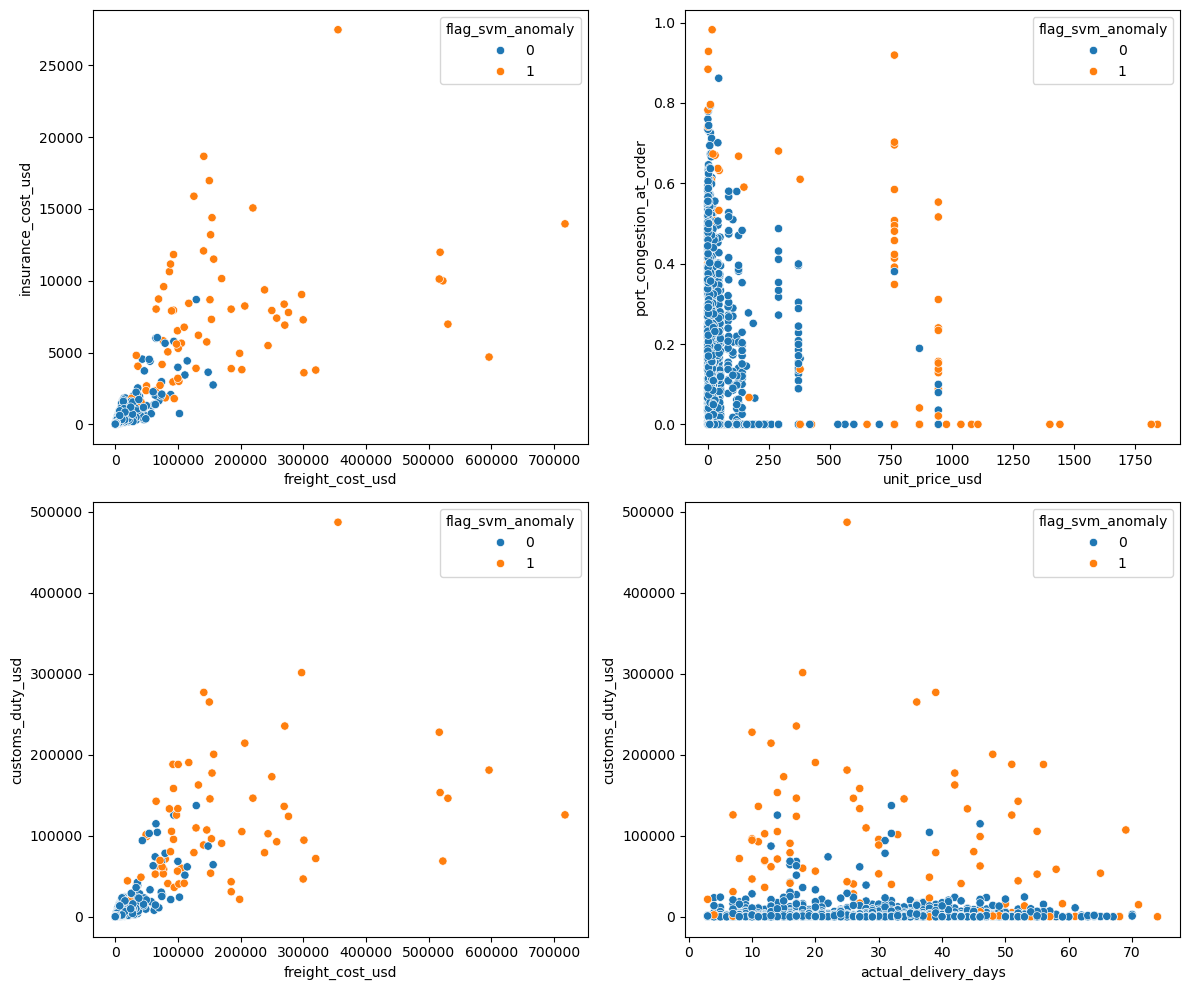

In [30]:
fig, ax = plt.subplots(2,2,figsize = (12,10))
sns.scatterplot(x = "freight_cost_usd", y = "insurance_cost_usd", data = data, hue = "flag_svm_anomaly", ax = ax[0,0])
sns.scatterplot(x = "unit_price_usd", y = "port_congestion_at_order", data = data, hue = "flag_svm_anomaly", ax = ax[0,1])
sns.scatterplot(x = "freight_cost_usd", y = "customs_duty_usd", data = data, hue = "flag_svm_anomaly", ax = ax[1,0])
sns.scatterplot(x = "actual_delivery_days", y = "customs_duty_usd", data = data, hue = "flag_svm_anomaly", ax = ax[1,1])
plt.tight_layout()
plt.show()

# AE

In [31]:
data_scaled = preprocessor.fit_transform(data[num_cols + cat_cols]).toarray()
X_tensor = torch.tensor(data_scaled, dtype=torch.float32)

dataset = TensorDataset(X_tensor)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 4)
        )

        self.decoder = nn.Sequential(
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, input_dim)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# Инициализация
input_dim = data_scaled.shape[1]
model = Autoencoder(input_dim)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Обучение
epochs = 30

for epoch in range(epochs):
    epoch_loss = 0

    for batch in loader:
        x = batch[0]

        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, x)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

# =========================
# Выявление аномалий
# =========================
model.eval()

with torch.no_grad():
    reconstructed = model(X_tensor)
    mse = torch.mean((X_tensor - reconstructed) ** 2, dim=1).numpy()

threshold = np.percentile(mse, 95)

data["flag_ae_anomaly"] = (mse > threshold)*1

print("Autoencoder anomalies:", data["flag_ae_anomaly"].sum())

Epoch 1, Loss: 19.8080
Epoch 2, Loss: 16.2010
Epoch 3, Loss: 14.1244
Epoch 4, Loss: 12.4463
Epoch 5, Loss: 11.0437
Epoch 6, Loss: 10.0824
Epoch 7, Loss: 9.4400
Epoch 8, Loss: 8.8953
Epoch 9, Loss: 8.4903
Epoch 10, Loss: 8.1857
Epoch 11, Loss: 7.9395
Epoch 12, Loss: 7.7526
Epoch 13, Loss: 7.5992
Epoch 14, Loss: 7.4853
Epoch 15, Loss: 7.3691
Epoch 16, Loss: 7.3173
Epoch 17, Loss: 7.2558
Epoch 18, Loss: 7.2087
Epoch 19, Loss: 7.1823
Epoch 20, Loss: 7.1505
Epoch 21, Loss: 7.1393
Epoch 22, Loss: 7.1543
Epoch 23, Loss: 7.0709
Epoch 24, Loss: 7.0562
Epoch 25, Loss: 7.0308
Epoch 26, Loss: 7.0278
Epoch 27, Loss: 7.0115
Epoch 28, Loss: 6.9755
Epoch 29, Loss: 6.9589
Epoch 30, Loss: 6.9366
Autoencoder anomalies: 124


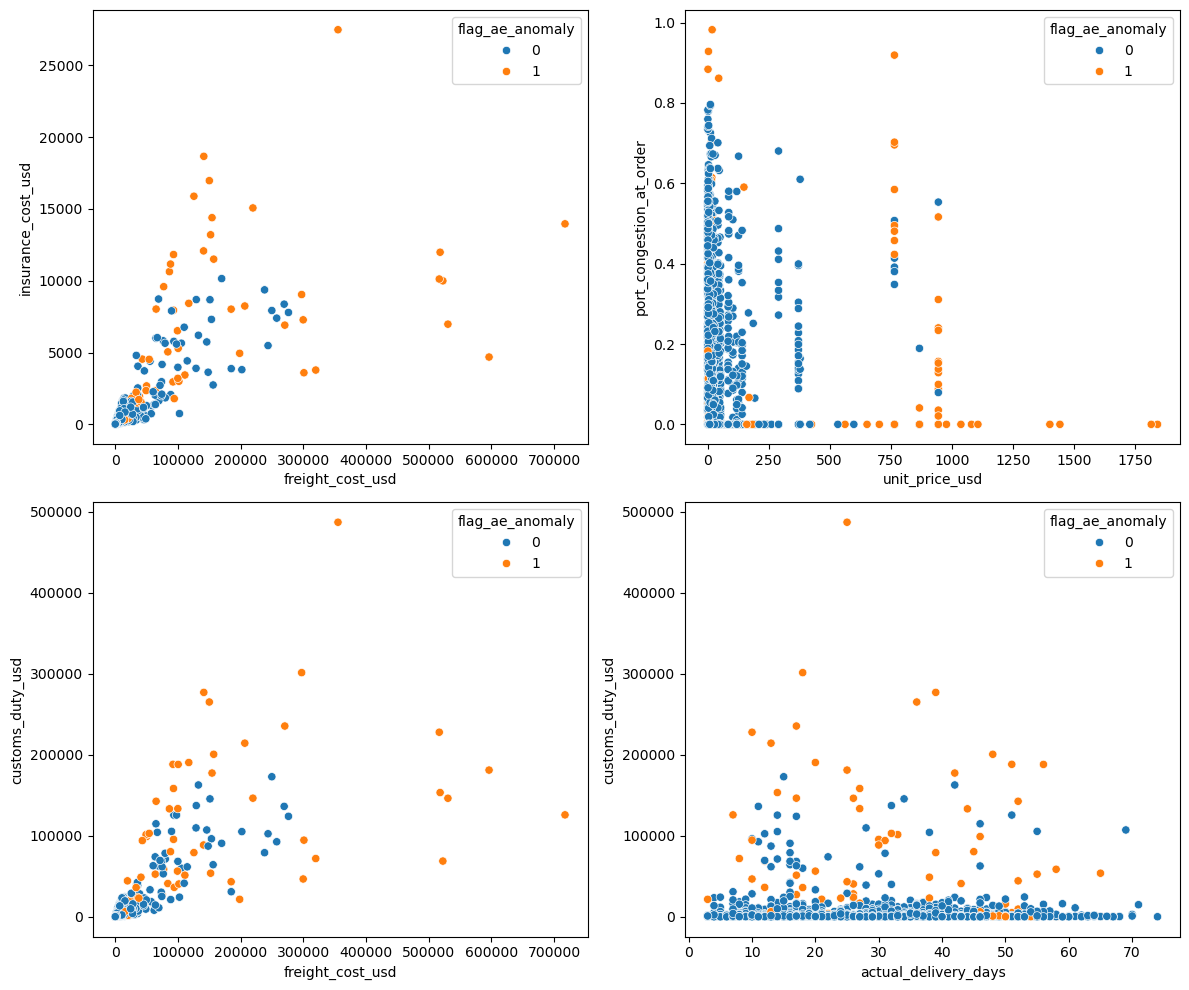

In [34]:
visualise_anomalies("flag_ae_anomaly")

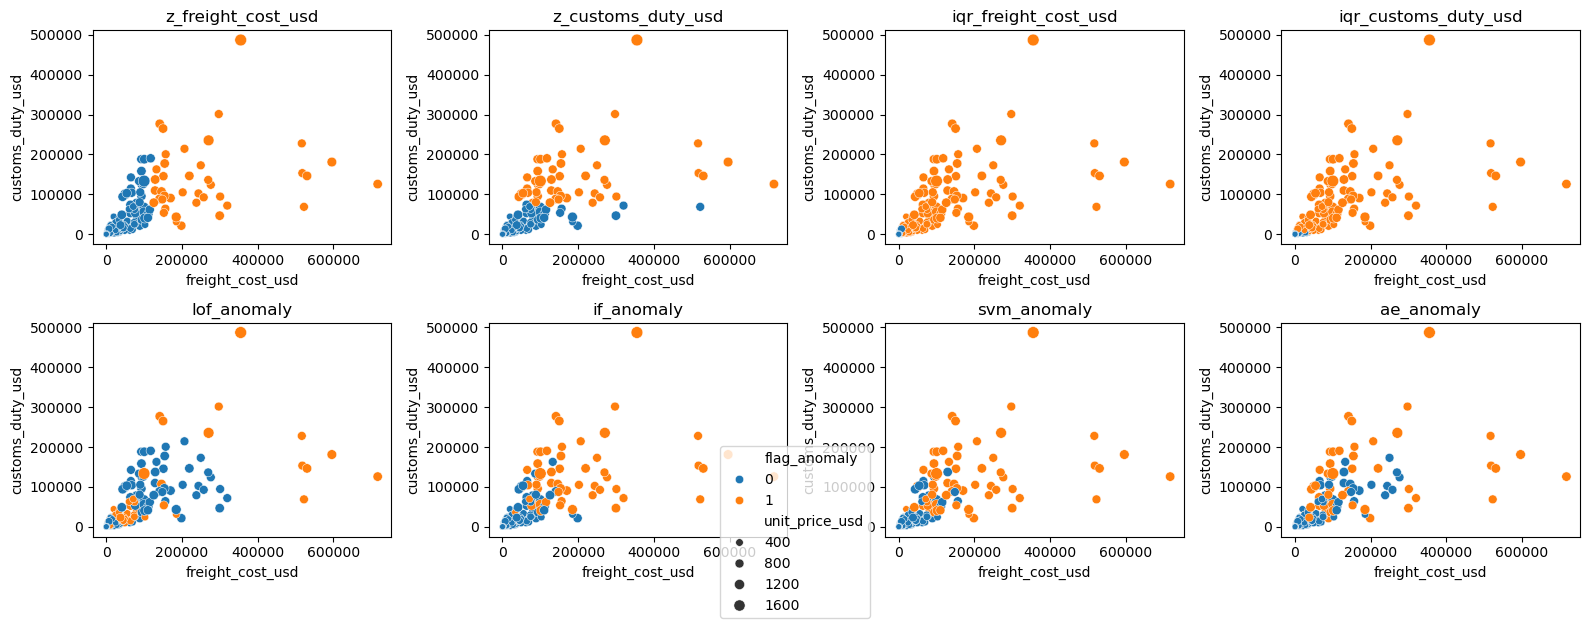

In [153]:
flag_cols = ['flag_z_freight_cost_usd', 'flag_z_customs_duty_usd', 'flag_iqr_freight_cost_usd', 'flag_iqr_customs_duty_usd',  'flag_lof_anomaly', 'flag_if_anomaly', 'flag_svm_anomaly', 'flag_ae_anomaly']

fig, axes = plt.subplots(2, 4, figsize = (16, 6))
for i, ax in enumerate(axes.flatten()):
    sns.scatterplot(x = "freight_cost_usd", y = "customs_duty_usd", data = data, size = "unit_price_usd", hue = flag_cols[i], ax = ax)
    ax.get_legend().remove()
    ax.set_title(flag_cols[i][5:])

# Create a single legend at the bottom
handles, labels = ax.get_legend_handles_labels()
labels[0] = "flag_anomaly"
fig.legend(handles, labels, loc='lower center', ncol=1, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()

In [41]:
anom_po_id = data[data[["flag_if_anomaly", "flag_lof_anomaly", "flag_svm_anomaly", "flag_ae_anomaly"]].any(axis = 1)].index
anom_df = df_po.loc[df_po["po_id"].isin(anom_po_id), ["po_id"]]
anom_df["flag_anomaly"] = 1
anom_df = anom_df.reset_index(drop = True)
anom_df.to_csv(f"{OUTPUT_DIR}\\fact_po_anomalies.csv", index = False)

In [170]:
anom_po_id = data[data[["flag_if_anomaly", "flag_lof_anomaly", "flag_svm_anomaly", "flag_ae_anomaly"]].any(axis = 1)].index
anom_df = df_po.loc[df_po["po_id"].isin(anom_po_id), ["po_id", "supplier_id", "transport_mode_id", "payment_method", "is_fraud"]]
anom_df["supplier_id"].value_counts()

supplier_id
13    51
3     38
8     36
23    26
24    16
7     15
1     12
22    10
20    10
17     9
5      7
14     7
25     6
4      5
6      5
19     5
16     4
2      4
21     4
11     4
15     3
12     3
18     3
10     3
26     3
9      2
Name: count, dtype: int64

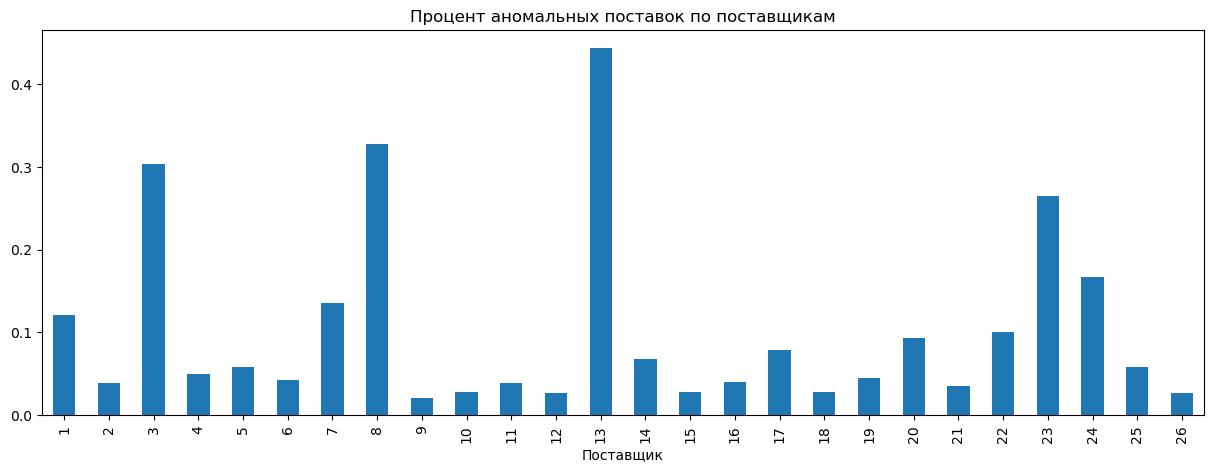

In [176]:
fig, ax = plt.subplots(1,1,figsize = (15,5))
(anom_df["supplier_id"].value_counts() / df_po["supplier_id"].value_counts()).plot(kind = "bar")
ax.set_title("Процент аномальных поставок по поставщикам")
ax.set_xlabel("Поставщик")
plt.show()

In [177]:
df_suppliers = pd.read_csv(f"{OUTPUT_DIR}\\dim_suppliers.csv")
df_suppliers.query("supplier_id == 13")

,supplier_id,supplier_name,country_id,city,primary_category_id,registration_date,years_of_relationship,reliability_score,maturity_score,payment_terms_days,min_order_usd,certifications,is_fraudster,active
12,13,Tata Industrial IN,IN,Mumbai,2,2013-02-02,5.9,0.673,9,60,6500,"[""GMP""]",False,True
